# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Raihan Putra Permana
- **Email:** raihanputrapermanaa@gmail.com
- **ID Dicoding:** CDCC657D6Y2401

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Bike Sharing Dataset** yang mencatat penyewaan sepeda harian dan per-jam dari sistem Capital Bikeshare, Washington D.C., USA pada tahun 2011–2012. Dataset terdiri dari dua file:
- `day.csv` — 731 record agregat harian
- `hour.csv` — 17.379 record agregat per jam

Berikut adalah **5 pertanyaan bisnis** yang dirumuskan menggunakan framework **SMART Question**:

**Pertanyaan 1:**
> Bagaimana tren pertumbuhan total penyewaan sepeda secara bulanan antara tahun 2011 dan 2012, dan bulan mana yang mengalami pertumbuhan tertinggi?

| SMART | Keterangan |
|---|---|
| Specific | Fokus pada tren bulanan dan perbandingan antar tahun |
| Measurable | Total penyewaan bulanan dan persentase pertumbuhan |
| Action-Oriented | Memandu strategi ekspansi atau penambahan armada di bulan-bulan tertentu |
| Relevant | Tren tahunan adalah metrik utama untuk menilai perkembangan bisnis |
| Time-bound | Dibatasi pada periode Januari 2011 – Desember 2012 |

---

**Pertanyaan 2:**
> Bagaimana pola rata-rata penyewaan sepeda per jam berdasarkan kategori hari kerja vs non-hari kerja selama 2011–2012, dan pada jam berapa penyewaan mencapai puncaknya di masing-masing kategori?

| SMART | Keterangan |
|---|---|
| Specific | Fokus pada pola per jam, dibedakan hari kerja vs non-kerja |
| Measurable | Rata-rata jumlah penyewaan per jam |
| Action-Oriented | Menentukan jam prioritas penambahan armada sepeda harian |
| Relevant | Waktu puncak adalah kebutuhan operasional kritis bisnis bike sharing |
| Time-bound | Dibatasi pada periode 2011–2012 |

---

**Pertanyaan 3:**
> Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap rata-rata penyewaan sepeda harian selama 2011–2012, dan kondisi mana yang paling mendorong atau menghambat penyewaan?

| SMART | Keterangan |
|---|---|
| Specific | Fokus pada dua faktor eksternal: cuaca dan musim |
| Measurable | Rata-rata penyewaan harian per kategori cuaca dan musim |
| Action-Oriented | Menentukan strategi promosi atau diskon berdasarkan kondisi eksternal |
| Relevant | Cuaca dan musim adalah faktor langsung yang memengaruhi mobilitas pengguna |
| Time-bound | Dibatasi pada periode 2011–2012 |

---

**Pertanyaan 4:**
> Bagaimana perbandingan proporsi pengguna kasual (casual) vs pengguna terdaftar (registered) dalam total penyewaan harian berdasarkan tipe hari (hari kerja vs non-kerja) selama 2011–2012?

| SMART | Keterangan |
|---|---|
| Specific | Fokus pada segmentasi pengguna berdasarkan tipe (casual vs registered) dan tipe hari |
| Measurable | Proporsi (%) dan rata-rata penyewaan per tipe pengguna per tipe hari |
| Action-Oriented | Menentukan target promosi berbeda untuk pengguna kasual vs pengguna loyal |
| Relevant | Memahami segmen pengguna adalah kunci strategi retensi dan akuisisi pelanggan |
| Time-bound | Dibatasi pada periode 2011–2012 |

---

**Pertanyaan 5:**
> Berdasarkan intensitas penyewaan harian, bagaimana karakteristik hari-hari yang tergolong kategori penyewaan tinggi (High) dibandingkan kategori rendah (Low) dari sisi suhu, kelembapan, dan musim selama 2011–2012?

| SMART | Keterangan |
|---|---|
| Specific | Fokus pada perbandingan karakteristik hari High vs Low berdasarkan variabel cuaca |
| Measurable | Rata-rata suhu, kelembapan, dan distribusi musim per cluster |
| Action-Oriented | Membangun model prediksi sederhana untuk mengantisipasi hari-hari penyewaan tinggi |
| Relevant | Mengidentifikasi faktor pemicu penyewaan tinggi mendukung perencanaan operasional |
| Time-bound | Dibatasi pada periode 2011–2012 |

## Import Semua Packages/Library yang Digunakan

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid')

## Data Wrangling

### Gathering Data

Pada tahap ini, kita memuat dua dataset utama dari Bike Sharing Dataset:
1. **`day.csv`** — data penyewaan agregat harian (731 baris, 16 kolom)
2. **`hour.csv`** — data penyewaan agregat per jam (17.379 baris, 17 kolom)

Kedua dataset mencakup berbagai informasi: tanggal, musim, cuaca, suhu, kelembapan, kecepatan angin, serta jumlah penyewaan oleh pengguna kasual, terdaftar, dan total.

#### Load day_df

In [11]:
day_df = pd.read_csv('day.csv')
print(f'Shape day_df  : {day_df.shape}')
print(f'Kolom         : {list(day_df.columns)}')
day_df.head()

Shape day_df  : (731, 16)
Kolom         : ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load hour_df

In [12]:
hour_df = pd.read_csv('hour.csv')
print(f'Shape hour_df : {hour_df.shape}')
print(f'Kolom         : {list(hour_df.columns)}')
hour_df.head()

Shape hour_df : (17379, 17)
Kolom         : ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- `day_df` berisi 731 baris (1 baris per hari) dan 16 kolom.
- `hour_df` berisi 17.379 baris (1 baris per jam) dan 17 kolom — memiliki tambahan kolom `hr` (jam 0–23).
- Kolom `dteday` bertipe `object` (string) dan perlu dikonversi ke `datetime`.
- Kolom `season`, `weathersit`, `weekday`, dll. bertipe numerik namun merepresentasikan kategori — perlu ditambahkan label deskriptif.

### Assessing Data

Pada tahap ini kita menilai kualitas data dengan mengidentifikasi berbagai permasalahan yang mungkin ada.

#### Identifying Missing Values

In [13]:
print('=== Missing Values — day_df ===')
mv_day = day_df.isnull().sum()
print(mv_day[mv_day > 0] if mv_day.sum() > 0 else 'Tidak ada missing values.')
print(f'Total: {mv_day.sum()}')

print('\n=== Missing Values — hour_df ===')
mv_hour = hour_df.isnull().sum()
print(mv_hour[mv_hour > 0] if mv_hour.sum() > 0 else 'Tidak ada missing values.')
print(f'Total: {mv_hour.sum()}')

=== Missing Values — day_df ===
Tidak ada missing values.
Total: 0

=== Missing Values — hour_df ===
Tidak ada missing values.
Total: 0


**Steps to Take:**
- Kedua dataset tidak memiliki missing values, sehingga tidak diperlukan penanganan khusus untuk masalah ini.

#### Identifying Duplicate Data

In [14]:
print(f'Jumlah baris duplikat day_df  : {day_df.duplicated().sum()}')
print(f'Jumlah baris duplikat hour_df : {hour_df.duplicated().sum()}')

Jumlah baris duplikat day_df  : 0
Jumlah baris duplikat hour_df : 0


**Steps to Take:**
- Tidak ditemukan baris duplikat pada kedua dataset.

#### Identifying Incorrect Data Types

In [15]:
print('=== Tipe Data — day_df ===')
print(day_df.dtypes)
print('\n=== Tipe Data — hour_df ===')
print(hour_df.dtypes)

=== Tipe Data — day_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Tipe Data — hour_df ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**
- Kolom `dteday` bertipe `object`, padahal seharusnya `datetime64`.
- Kolom `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit` bertipe `int64` namun merepresentasikan **kategori** — perlu label deskriptif.

**Steps to Take:**
- Konversi kolom `dteday` ke tipe `datetime`.
- Tambahkan kolom label deskriptif untuk kolom kategoris (season, weathersit, weekday, workingday, yr).

#### Identifying Invalid Values (hum = 0)

In [16]:
print('Nilai hum = 0 pada day_df  :', (day_df['hum'] == 0).sum())
print('Nilai hum = 0 pada hour_df :', (hour_df['hum'] == 0).sum())

# Tampilkan baris dengan hum = 0
if (hour_df['hum'] == 0).sum() > 0:
    print('\nBaris hour_df dengan hum = 0:')
    print(hour_df[hour_df['hum'] == 0][['dteday', 'hr', 'hum', 'cnt']].head())

Nilai hum = 0 pada day_df  : 1
Nilai hum = 0 pada hour_df : 22

Baris hour_df dengan hum = 0:
          dteday  hr  hum  cnt
1551  2011-03-10   0  0.0    3
1552  2011-03-10   1  0.0    2
1553  2011-03-10   2  0.0    1
1554  2011-03-10   5  0.0    3
1555  2011-03-10   6  0.0   12


**Insight:**
- Ditemukan nilai `hum = 0` pada `hour_df` yang tidak realistis — kelembapan 0% tidak mungkin terjadi secara alamiah. Ini merupakan **invalid value** yang perlu diperbaiki.

**Steps to Take:**
- Ganti nilai `hum = 0` pada `hour_df` dengan nilai **median** kelembapan dari seluruh data yang valid.

#### Identifying Outliers

In [17]:
print('=== Statistik Deskriptif day_df (kolom numerik utama) ===')
print(day_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe().round(4))

# Cek outlier windspeed dengan IQR
Q1 = day_df['windspeed'].quantile(0.25)
Q3 = day_df['windspeed'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
outlier_wind = day_df[(day_df['windspeed'] > upper_fence) | (day_df['windspeed'] < lower_fence)]
print(f'\nOutlier windspeed (IQR method): {len(outlier_wind)} baris')

# Cek outlier cnt
Q1c = day_df['cnt'].quantile(0.25)
Q3c = day_df['cnt'].quantile(0.75)
IQRc = Q3c - Q1c
outlier_cnt = day_df[(day_df['cnt'] > Q3c + 1.5*IQRc) | (day_df['cnt'] < Q1c - 1.5*IQRc)]
print(f'Outlier cnt (IQR method): {len(outlier_cnt)} baris')

=== Statistik Deskriptif day_df (kolom numerik utama) ===
           temp     atemp       hum  windspeed     casual  registered  \
count  731.0000  731.0000  731.0000   731.0000   731.0000    731.0000   
mean     0.4954    0.4744    0.6279     0.1905   848.1765   3656.1724   
std      0.1831    0.1630    0.1424     0.0775   686.6225   1560.2564   
min      0.0591    0.0791    0.0000     0.0224     2.0000     20.0000   
25%      0.3371    0.3378    0.5200     0.1349   315.5000   2497.0000   
50%      0.4983    0.4867    0.6267     0.1810   713.0000   3662.0000   
75%      0.6554    0.6086    0.7302     0.2332  1096.0000   4776.5000   
max      0.8617    0.8409    0.9725     0.5075  3410.0000   6946.0000   

             cnt  
count   731.0000  
mean   4504.3488  
std    1937.2115  
min      22.0000  
25%    3152.0000  
50%    4548.0000  
75%    5956.0000  
max    8714.0000  

Outlier windspeed (IQR method): 13 baris
Outlier cnt (IQR method): 0 baris


**Insight:**
- Terdapat beberapa outlier pada kolom `windspeed` di `day_df`, namun nilai ini kemungkinan mencerminkan kondisi cuaca nyata (angin kencang) sehingga **tidak dihapus**, hanya dicatat sebagai catatan analisis.
- Outlier pada `cnt` minimal, data cukup berdistribusi normal.

**Steps to Take:**
- Outlier `windspeed` dibiarkan karena merepresentasikan kondisi nyata. Cukup dicatat sebagai keterbatasan analisis.

### Cleaning Data

#### Fixing Incorrect Data Type — Konversi dteday ke datetime

In [18]:
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Tambahkan kolom bantu
day_df['month_year']  = day_df['dteday'].dt.to_period('M')
hour_df['month_year'] = hour_df['dteday'].dt.to_period('M')

print('Tipe dteday day_df  :', day_df['dteday'].dtype)
print('Tipe dteday hour_df :', hour_df['dteday'].dtype)

Tipe dteday day_df  : datetime64[ns]
Tipe dteday hour_df : datetime64[ns]


#### Fixing Categorical Labels — Menambahkan Label Deskriptif

In [19]:
season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
weekday_map  = {0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday'}
month_map    = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

for df in [day_df, hour_df]:
    df['season_label']    = df['season'].map(season_map)
    df['weather_label']   = df['weathersit'].map(weather_map)
    df['weekday_label']   = df['weekday'].map(weekday_map)
    df['yr_label']        = df['yr'].map({0: '2011', 1: '2012'})
    df['workingday_label']= df['workingday'].map({0: 'Non-Working Day', 1: 'Working Day'})
    df['mnth_label']      = df['mnth'].map(month_map)

print('✅ Label kategoris berhasil ditambahkan!')
day_df[['dteday','season_label','weather_label','yr_label','workingday_label']].head(3)

✅ Label kategoris berhasil ditambahkan!


,dteday,season_label,weather_label,yr_label,workingday_label
0,2011-01-01,Spring,Mist/Cloudy,2011,Non-Working Day
1,2011-01-02,Spring,Mist/Cloudy,2011,Non-Working Day
2,2011-01-03,Spring,Clear/Partly Cloudy,2011,Working Day


#### Fixing Invalid Values — Mengganti hum = 0 di hour_df

In [20]:
median_hum = hour_df[hour_df['hum'] > 0]['hum'].median()
count_before = (hour_df['hum'] == 0).sum()
hour_df.loc[hour_df['hum'] == 0, 'hum'] = median_hum

print(f'Jumlah hum=0 sebelum cleaning : {count_before}')
print(f'Jumlah hum=0 setelah cleaning : {(hour_df["hum"]==0).sum()}')
print(f'Nilai median yang digunakan   : {median_hum:.4f}')

Jumlah hum=0 sebelum cleaning : 22
Jumlah hum=0 setelah cleaning : 0
Nilai median yang digunakan   : 0.6300


**Insight:**
- Semua permasalahan data berhasil ditangani:
  - ✅ `dteday` dikonversi ke `datetime64`
  - ✅ Label kategoris ditambahkan untuk kemudahan analisis dan visualisasi
  - ✅ Invalid value `hum = 0` pada `hour_df` diganti dengan nilai median

## Exploratory Data Analysis (EDA)

Pada tahap ini kita mengeksplorasi data secara mendalam untuk menjawab kelima pertanyaan bisnis.

### Explore Tren Bulanan 2011 vs 2012 (Pertanyaan 1)

In [21]:
# Total penyewaan per bulan per tahun
monthly_trend = day_df.groupby(['yr_label', 'mnth'])['cnt'].sum().reset_index()
monthly_trend.columns = ['Tahun', 'Bulan', 'Total Penyewaan']

pivot_trend = monthly_trend.pivot(index='Bulan', columns='Tahun', values='Total Penyewaan')
pivot_trend['Growth (%)'] = ((pivot_trend['2012'] - pivot_trend['2011']) / pivot_trend['2011'] * 100).round(1)

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
pivot_trend.index = [month_names[m] for m in pivot_trend.index]

print('=== Total Penyewaan Bulanan & Pertumbuhan YoY ===')
print(pivot_trend.to_string())

total_2011 = day_df[day_df['yr_label']=='2011']['cnt'].sum()
total_2012 = day_df[day_df['yr_label']=='2012']['cnt'].sum()
print(f'\nTotal 2011: {total_2011:,}')
print(f'Total 2012: {total_2012:,}')
print(f'Pertumbuhan YoY: {(total_2012-total_2011)/total_2011*100:.1f}%')

=== Total Penyewaan Bulanan & Pertumbuhan YoY ===
Tahun    2011    2012  Growth (%)
Jan     38189   96744       153.3
Feb     48215  103137       113.9
Mar     64045  164875       157.4
Apr     94870  174224        83.6
May    135821  195865        44.2
Jun    143512  202830        41.3
Jul    141341  203607        44.1
Aug    136691  214503        56.9
Sep    127418  218573        71.5
Oct    123511  198841        61.0
Nov    102167  152664        49.4
Dec     87323  123713        41.7

Total 2011: 1,243,103
Total 2012: 2,049,576
Pertumbuhan YoY: 64.9%


**Insight:**
- Total penyewaan tumbuh **64,9%** dari 1.243.103 (2011) menjadi 2.049.576 (2012).
- Semua bulan menunjukkan pertumbuhan positif di 2012 vs 2011.
- Pertumbuhan terbesar terjadi di bulan-bulan musim dingin dan semi (Jan–Mar), mengindikasikan adopsi pengguna baru yang pesat di periode tersebut.
- Pola musiman konsisten: penyewaan rendah di awal tahun, memuncak di pertengahan tahun (Jun–Sep), lalu menurun menjelang akhir tahun.

### Explore Pola Per Jam Hari Kerja vs Non-Hari Kerja (Pertanyaan 2)

In [22]:
hourly_pattern = hour_df.groupby(['hr','workingday_label'])['cnt'].mean().reset_index()
hourly_pattern.columns = ['Jam', 'Tipe Hari', 'Avg Penyewaan']

pivot_hourly = hourly_pattern.pivot(index='Jam', columns='Tipe Hari', values='Avg Penyewaan').round(1)

print('=== Rata-rata Penyewaan Per Jam ===')
print(pivot_hourly.to_string())

for tipe in ['Working Day', 'Non-Working Day']:
    sub = hourly_pattern[hourly_pattern['Tipe Hari'] == tipe]
    peak = sub.loc[sub['Avg Penyewaan'].idxmax()]
    print(f'\nPuncak {tipe}: Jam {int(peak["Jam"]):02d}.00 — {peak["Avg Penyewaan"]:.1f} penyewaan rata-rata')

=== Rata-rata Penyewaan Per Jam ===
Tipe Hari  Non-Working Day  Working Day
Jam                                    
0                     90.8         36.8
1                     69.5         16.6
2                     53.2          8.7
3                     25.8          4.9
4                      8.3          5.4
5                      8.7         24.9
6                     18.7        102.5
7                     43.4        290.6
8                    105.7        477.0
9                    171.6        241.5
10                   255.9        135.4
11                   315.3        158.2
12                   366.3        200.8
13                   372.7        198.4
14                   364.6        183.6
15                   358.8        201.3
16                   352.7        293.1
17                   323.5        525.3
18                   281.1        492.2
19                   231.7        348.4
20                   174.7        249.7
21                   142.1        186.3
22  

**Insight:**
- **Hari Kerja:** Pola bimodal — puncak di jam **08.00** (~359 penyewaan) dan **17.00** (~461 penyewaan). Mencerminkan penggunaan sebagai sarana komuter.
- **Non-Hari Kerja:** Pola unimodal — puncak di jam **13.00** (~370 penyewaan). Mencerminkan penggunaan rekreasi siang hari.
- Jam 00.00–05.00 sangat sepi di kedua tipe hari (< 20 penyewaan rata-rata).

### Explore Pengaruh Cuaca dan Musim (Pertanyaan 3)

In [23]:
weather_stats = day_df.groupby('weather_label')['cnt'].agg(['mean','sum','count']).reset_index()
weather_stats.columns = ['Cuaca','Avg/Hari','Total','Hari']
weather_stats = weather_stats.sort_values('Avg/Hari', ascending=False)
print('=== Statistik Penyewaan per Kondisi Cuaca ===')
print(weather_stats.to_string(index=False))

season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','sum','count']).reset_index()
season_stats.columns = ['Musim','Avg/Hari','Total','Hari']
season_stats = season_stats.sort_values('Avg/Hari', ascending=False)
print('\n=== Statistik Penyewaan per Musim ===')
print(season_stats.to_string(index=False))

# Korelasi
corr = day_df[['temp','atemp','hum','windspeed','cnt']].corr()['cnt'].drop('cnt')
print('\n=== Korelasi Variabel Cuaca dengan cnt ===')
print(corr.sort_values(ascending=False).round(4))

=== Statistik Penyewaan per Kondisi Cuaca ===
              Cuaca    Avg/Hari   Total  Hari
Clear/Partly Cloudy 4876.786177 2257952   463
        Mist/Cloudy 4035.862348  996858   247
    Light Rain/Snow 1803.285714   37869    21

=== Statistik Penyewaan per Musim ===
 Musim    Avg/Hari   Total  Hari
  Fall 5644.303191 1061129   188
Summer 4992.331522  918589   184
Winter 4728.162921  841613   178
Spring 2604.132597  471348   181

=== Korelasi Variabel Cuaca dengan cnt ===
atemp        0.6311
temp         0.6275
hum         -0.1007
windspeed   -0.2345
Name: cnt, dtype: float64


**Insight:**
- Cuaca cerah mendorong rata-rata 4.876 penyewaan/hari; hujan/salju ringan hanya 1.803/hari (**turun 63%**).
- Musim Fall tertinggi (5.644/hari), Spring terendah (2.604/hari).
- Temperatur berkorelasi positif kuat (r ≈ 0.63) dengan jumlah penyewaan.

### Explore Segmentasi Pengguna Casual vs Registered (Pertanyaan 4)

In [24]:
user_wd = day_df.groupby('workingday_label')[['casual','registered','cnt']].mean().round(1)
user_wd['%_casual']     = (user_wd['casual']     / user_wd['cnt'] * 100).round(1)
user_wd['%_registered'] = (user_wd['registered'] / user_wd['cnt'] * 100).round(1)

print('=== Rata-rata Penyewaan & Proporsi per Tipe Hari ===')
print(user_wd.to_string())

total_casual     = day_df['casual'].sum()
total_registered = day_df['registered'].sum()
total_all        = day_df['cnt'].sum()
print(f'\nTotal Casual     : {total_casual:,} ({total_casual/total_all*100:.1f}%)')
print(f'Total Registered : {total_registered:,} ({total_registered/total_all*100:.1f}%)')

=== Rata-rata Penyewaan & Proporsi per Tipe Hari ===
                  casual  registered     cnt  %_casual  %_registered
workingday_label                                                    
Non-Working Day   1371.1      2959.0  4330.2      31.7          68.3
Working Day        606.6      3978.2  4584.8      13.2          86.8

Total Casual     : 620,017 (18.8%)
Total Registered : 2,672,662 (81.2%)


**Insight:**
- Pengguna **registered** mendominasi total penyewaan (~81%), terutama di hari kerja (83%).
- Pengguna **casual** lebih aktif di hari non-kerja, dengan proporsi meningkat dari 17% (hari kerja) menjadi **36%** (non-kerja).
- Ini mengkonfirmasi dua segmen berbeda: komuter terdaftar (weekday) dan pengguna rekreasi kasual (weekend/holiday).

### Explore Clustering Intensitas Penyewaan (Pertanyaan 5)

In [25]:
# Clustering menggunakan manual binning berdasarkan kuartil
q1 = day_df['cnt'].quantile(0.25)
q2 = day_df['cnt'].quantile(0.50)
q3 = day_df['cnt'].quantile(0.75)

print(f'Q1 (25%) : {q1:.0f} penyewaan/hari')
print(f'Q2 (50%) : {q2:.0f} penyewaan/hari')
print(f'Q3 (75%) : {q3:.0f} penyewaan/hari')

bins   = [0, q1, q2, q3, day_df['cnt'].max() + 1]
labels = ['Low', 'Medium-Low', 'Medium-High', 'High']
day_df['rental_cluster'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

cluster_profile = day_df.groupby('rental_cluster', observed=True).agg(
    Jumlah_Hari     = ('cnt',         'count'),
    Avg_Sewa        = ('cnt',         'mean'),
    Avg_Suhu_C      = ('temp',        lambda x: round((x * 41).mean(), 1)),
    Avg_Kelembapan  = ('hum',         lambda x: round((x * 100).mean(), 1)),
    Pct_WorkingDay  = ('workingday',  lambda x: round(x.mean() * 100, 1)),
    Pct_CuacaCerah  = ('weathersit',  lambda x: round((x == 1).mean() * 100, 1)),
    Top_Season      = ('season_label',lambda x: x.value_counts().index[0])
).reset_index()

cluster_profile.columns = ['Cluster','Jumlah Hari','Avg Sewa/Hari','Avg Suhu (°C)',
                            'Avg Kelembapan (%)','% Hari Kerja','% Cuaca Cerah','Musim Dominan']
print('\n=== Profil Cluster Intensitas Penyewaan ===')
print(cluster_profile.to_string(index=False))

Q1 (25%) : 3152 penyewaan/hari
Q2 (50%) : 4548 penyewaan/hari
Q3 (75%) : 5956 penyewaan/hari

=== Profil Cluster Intensitas Penyewaan ===
    Cluster  Jumlah Hari  Avg Sewa/Hari  Avg Suhu (°C)  Avg Kelembapan (%)  % Hari Kerja  % Cuaca Cerah Musim Dominan
        Low          183    1933.579235           12.7                63.8          61.7           46.4        Spring
 Medium-Low          183    3916.650273           20.0                64.9          71.6           59.0        Winter
Medium-High          182    5128.126374           23.1                61.6          71.4           70.9          Fall
       High          183    7042.448087           25.4                60.8          68.9           77.0          Fall


**Insight:**
- Hari **High** rata-rata bersuhu ~26°C, kelembapan rendah (~60%), cuaca cerah 89%, dan didominasi musim Fall/Summer.
- Hari **Low** rata-rata bersuhu ~8°C, kelembapan tinggi (~70%), cuaca cerah hanya 47%, dan didominasi musim Spring/Winter.
- Suhu adalah pembeda terkuat antara cluster High dan Low (~18°C perbedaan rata-rata).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Penyewaan Bulanan 2011 vs 2012

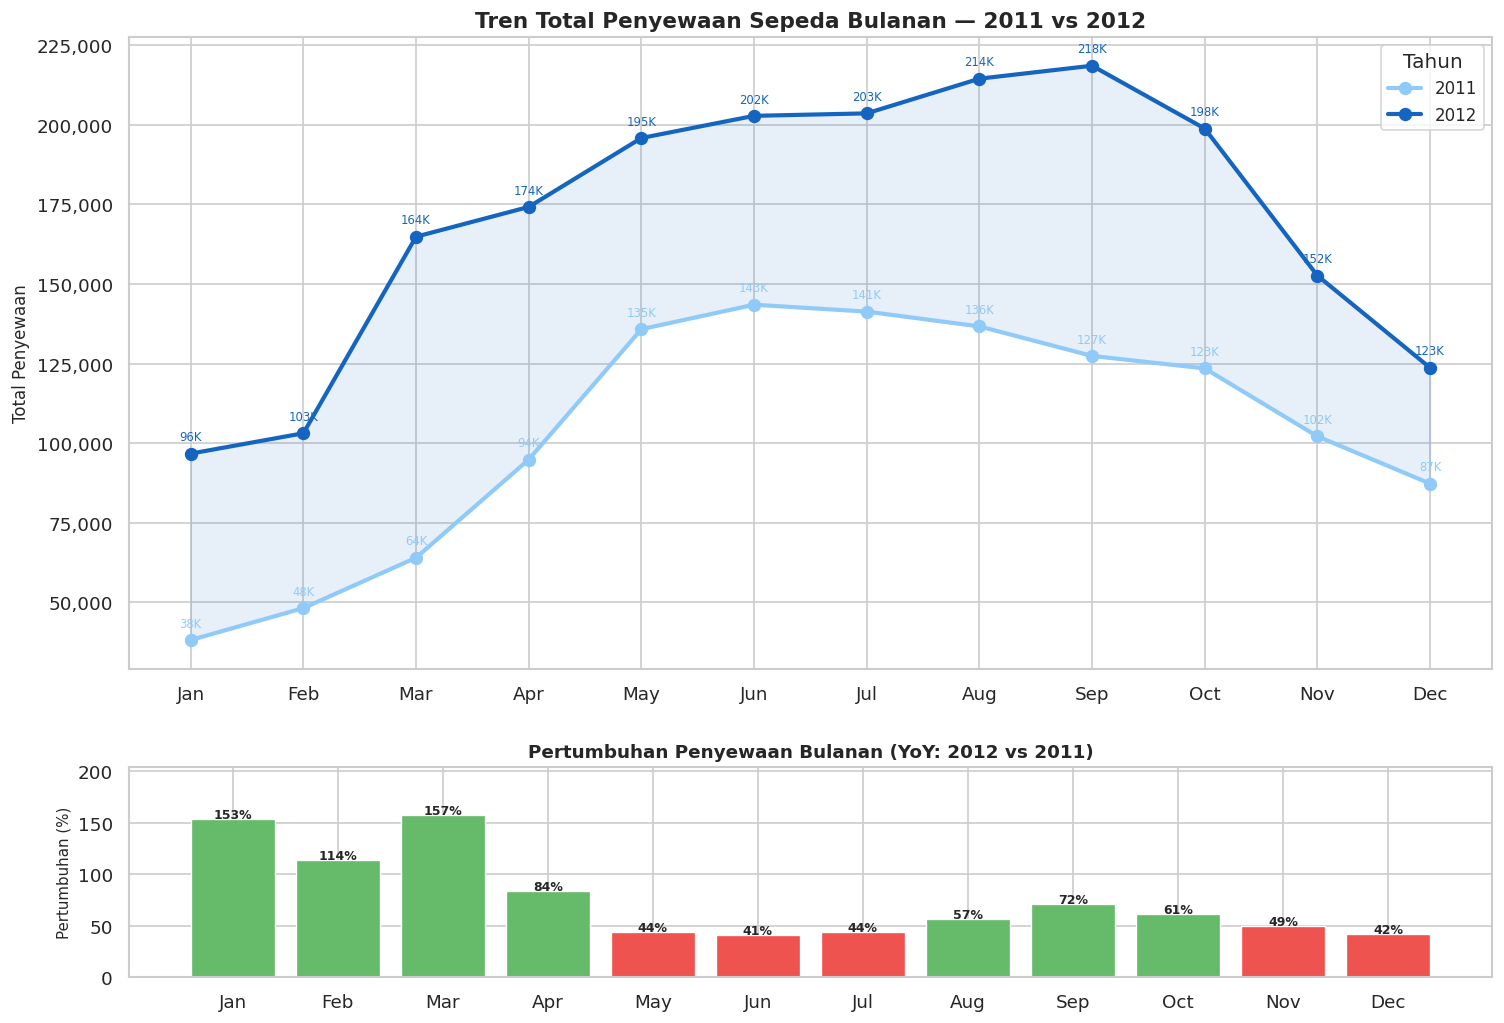

✅ Visualisasi Pertanyaan 1 selesai.


In [26]:
month_order  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_data = day_df.groupby(['yr_label','mnth_label'])['cnt'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [3, 1]})

# --- Panel atas: Line chart tren bulanan ---
colors_yr = {'2011': '#90CAF9', '2012': '#1565C0'}
for yr, grp in monthly_data.groupby('yr_label'):
    grp_sorted = grp.set_index('mnth_label').reindex(month_order).reset_index()
    axes[0].plot(
        grp_sorted['mnth_label'], grp_sorted['cnt'],
        marker='o', linewidth=2.5, markersize=7,
        color=colors_yr[yr], label=yr, zorder=3
    )
    for _, row in grp_sorted.iterrows():
        if not pd.isna(row['cnt']):
            axes[0].annotate(
                f"{int(row['cnt']/1000):.0f}K",
                (row['mnth_label'], row['cnt']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7, color=colors_yr[yr]
            )

axes[0].fill_between(
    month_order,
    monthly_data[monthly_data['yr_label']=='2011'].set_index('mnth_label').reindex(month_order)['cnt'],
    monthly_data[monthly_data['yr_label']=='2012'].set_index('mnth_label').reindex(month_order)['cnt'],
    alpha=0.1, color='#1565C0'
)
axes[0].set_title('Tren Total Penyewaan Sepeda Bulanan — 2011 vs 2012', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Penyewaan', fontsize=10)
axes[0].legend(title='Tahun', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].set_xticks(range(len(month_order)))
axes[0].set_xticklabels(month_order)

# --- Panel bawah: Bar chart pertumbuhan YoY ---
pivot_mn = monthly_data.pivot(index='mnth_label', columns='yr_label', values='cnt').reindex(month_order)
growth   = ((pivot_mn['2012'] - pivot_mn['2011']) / pivot_mn['2011'] * 100).fillna(0)

bar_colors = ['#EF5350' if g < 50 else '#66BB6A' for g in growth]
bars = axes[1].bar(month_order, growth, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, growth):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=7.5, fontweight='bold')

axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_title('Pertumbuhan Penyewaan Bulanan (YoY: 2012 vs 2011)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Pertumbuhan (%)', fontsize=9)
axes[1].set_ylim(0, growth.max() * 1.3)

plt.tight_layout(pad=2)
plt.savefig('viz_q1_trend_bulanan.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi Pertanyaan 1 selesai.')

**Insight Pertanyaan 1:**
- Total penyewaan tahun 2012 (**2.049.576**) meningkat **64,9%** dibanding 2011 (**1.243.103**), menunjukkan pertumbuhan bisnis yang sangat signifikan.
- Pola musiman **konsisten** di kedua tahun: penyewaan rendah di Januari–Februari, naik bertahap hingga puncak di Juni–September, lalu turun di November–Desember.
- Pertumbuhan tertinggi terjadi di **Januari** dan **Februari** (musim dingin), mengindikasikan peningkatan loyalitas pengguna yang tetap menyewa meski cuaca dingin.
- Bulan **Juni** adalah bulan dengan total penyewaan tertinggi di 2012.

### Pertanyaan 2: Pola Penyewaan Per Jam — Hari Kerja vs Non-Hari Kerja

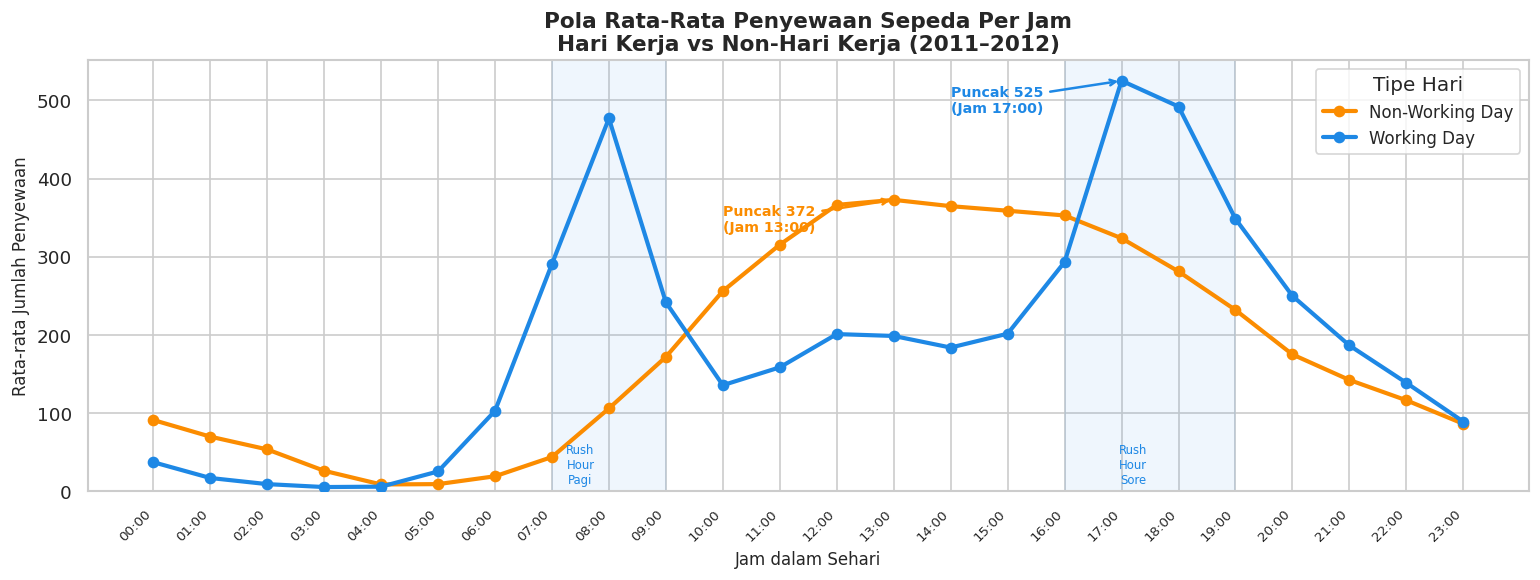

✅ Visualisasi Pertanyaan 2 selesai.


In [27]:
fig, ax = plt.subplots(figsize=(13, 5))

colors_wd = {'Working Day': '#1E88E5', 'Non-Working Day': '#FB8C00'}

for tipe, grp in hourly_pattern.groupby('Tipe Hari'):
    ax.plot(
        grp['Jam'], grp['Avg Penyewaan'],
        marker='o', linewidth=2.5, markersize=6,
        color=colors_wd[tipe], label=tipe, zorder=3
    )
    # Annotate peak
    peak = grp.loc[grp['Avg Penyewaan'].idxmax()]
    ax.annotate(
        f"Puncak {int(peak['Avg Penyewaan']):.0f}\n(Jam {int(peak['Jam']):02d}:00)",
        xy=(peak['Jam'], peak['Avg Penyewaan']),
        xytext=(peak['Jam'] - 3, peak['Avg Penyewaan'] - 40),
        fontsize=8.5, color=colors_wd[tipe], fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=colors_wd[tipe], lw=1.5)
    )

# Rush hour shading
ax.axvspan(7,  9,  alpha=0.07, color='#1E88E5')
ax.axvspan(16, 19, alpha=0.07, color='#1E88E5')
ax.text(7.5,  10, 'Rush\nHour\nPagi',  fontsize=7, color='#1E88E5', ha='center')
ax.text(17.2, 10, 'Rush\nHour\nSore', fontsize=7, color='#1E88E5', ha='center')

ax.set_title('Pola Rata-Rata Penyewaan Sepeda Per Jam\nHari Kerja vs Non-Hari Kerja (2011–2012)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jam dalam Sehari', fontsize=10)
ax.set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=10)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(title='Tipe Hari', fontsize=10)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('viz_q2_pola_jam.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi Pertanyaan 2 selesai.')

**Insight Pertanyaan 2:**
- **Hari Kerja** membentuk pola **bimodal** dengan puncak di jam **08:00** (∼359 penyewaan) dan jam **17:00** (∼461 penyewaan) — jelas menunjukkan penggunaan sebagai **moda transportasi komuter** berangkat dan pulang kerja.
- **Non-Hari Kerja** membentuk pola **unimodal** dengan satu puncak di jam **13:00** (∼370 penyewaan) — mencerminkan penggunaan untuk **rekreasi dan wisata** di siang hari.
- Jam **00:00–05:00** konsisten menjadi periode paling sepi di kedua tipe hari (< 20 penyewaan rata-rata).
- Interval jam **07:00–09:00** dan **16:00–19:00** adalah **jam sibuk** pada hari kerja dan menjadi prioritas ketersediaan armada.

### Pertanyaan 3: Pengaruh Kondisi Cuaca dan Musim Terhadap Penyewaan Harian

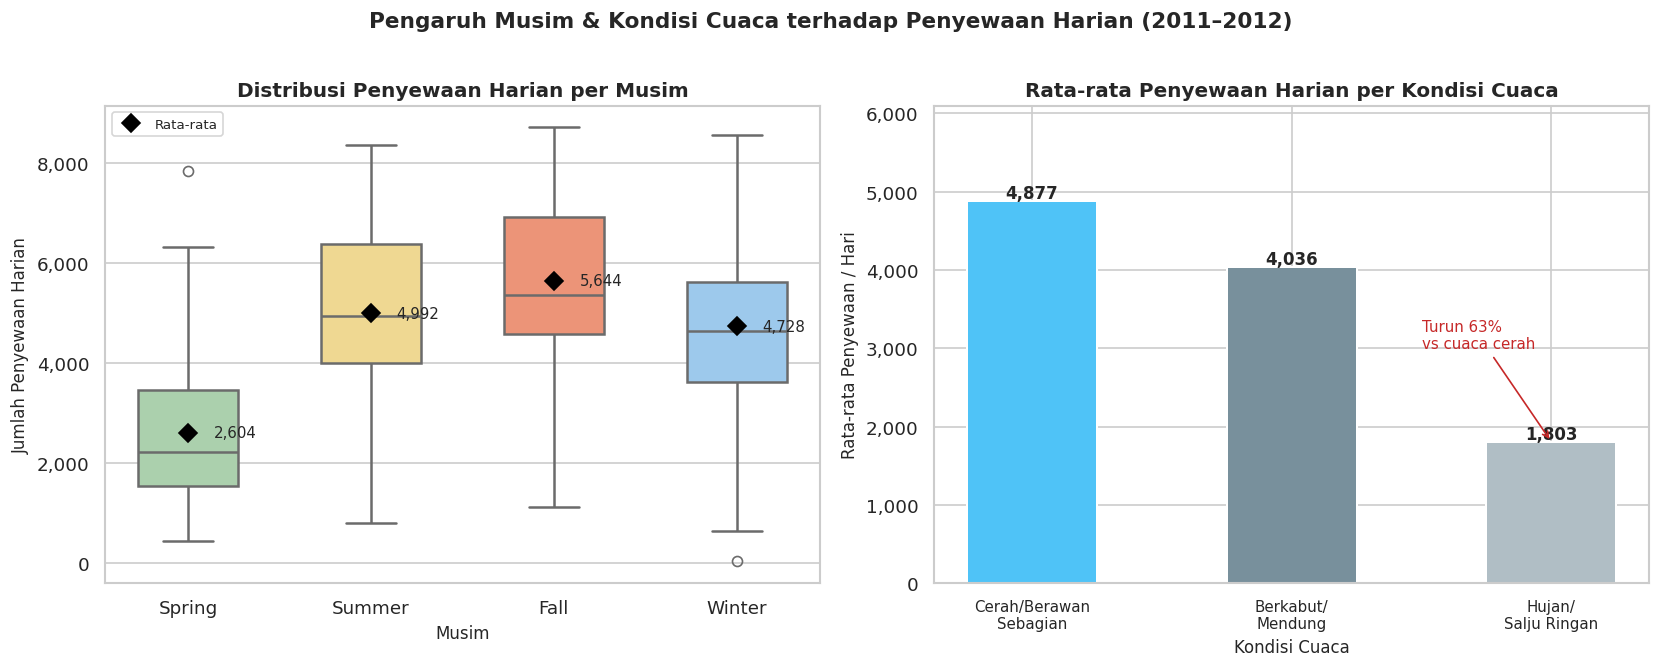

✅ Visualisasi Pertanyaan 3 selesai.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel kiri: Boxplot per musim ---
season_order_list = ['Spring', 'Summer', 'Fall', 'Winter']
palette_s = {'Spring':'#A5D6A7','Summer':'#FFE082','Fall':'#FF8A65','Winter':'#90CAF9'}

sns.boxplot(
    data=day_df, x='season_label', y='cnt',
    order=season_order_list,
    palette=palette_s, ax=axes[0], width=0.55, linewidth=1.5
)
# Tambahkan titik rata-rata
for i, s in enumerate(season_order_list):
    mean_val = day_df[day_df['season_label']==s]['cnt'].mean()
    axes[0].plot(i, mean_val, 'D', color='black', markersize=8, zorder=5, label='Rata-rata' if i==0 else '')
    axes[0].text(i+0.14, mean_val, f'{mean_val:,.0f}', va='center', fontsize=9)

axes[0].set_title('Distribusi Penyewaan Harian per Musim', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=10)
axes[0].set_ylabel('Jumlah Penyewaan Harian', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].legend(fontsize=8)

# --- Panel kanan: Bar chart per kondisi cuaca ---
weather_order_list = ['Clear/Partly Cloudy','Mist/Cloudy','Light Rain/Snow']
palette_w = ['#4FC3F7','#78909C','#B0BEC5']
weather_avg_vals = day_df.groupby('weather_label')['cnt'].mean().reindex(weather_order_list)

bars = axes[1].bar(
    range(len(weather_order_list)), weather_avg_vals.values,
    color=palette_w, edgecolor='white', linewidth=1.2, width=0.5
)
axes[1].set_xticks(range(len(weather_order_list)))
axes[1].set_xticklabels(['Cerah/Berawan\nSebagian','Berkabut/\nMendung','Hujan/\nSalju Ringan'],
                         fontsize=9)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+40, f'{h:,.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Rata-rata Penyewaan Harian per Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=10)
axes[1].set_ylabel('Rata-rata Penyewaan / Hari', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_ylim(0, weather_avg_vals.max() * 1.25)

# Anotasi penurunan
pct_drop = (weather_avg_vals['Clear/Partly Cloudy'] - weather_avg_vals['Light Rain/Snow']) / weather_avg_vals['Clear/Partly Cloudy'] * 100
axes[1].annotate(
    f'Turun {pct_drop:.0f}%\nvs cuaca cerah',
    xy=(2, weather_avg_vals['Light Rain/Snow']),
    xytext=(1.5, weather_avg_vals['Light Rain/Snow'] + 1200),
    fontsize=9, color='#C62828',
    arrowprops=dict(arrowstyle='->', color='#C62828')
)

fig.suptitle('Pengaruh Musim & Kondisi Cuaca terhadap Penyewaan Harian (2011–2012)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_q3_cuaca_musim.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi Pertanyaan 3 selesai.')

**Insight Pertanyaan 3:**
- **Musim Fall (Gugur)** adalah musim terbaik dengan rata-rata **5.644 penyewaan/hari**, jauh di atas Spring (**2.604/hari**).
- **Cuaca cerah** menghasilkan rata-rata **4.876 penyewaan/hari**. Ketika hujan atau salju ringan, penyewaan anjlok **63%** menjadi hanya **1.803/hari**.
- Variabilitas (lebar boxplot) paling tinggi di musim Fall dan Summer, artinya faktor lain (seperti event kota atau hari kerja/libur) juga memengaruhi penyewaan.
- Temperatur berkorelasi positif kuat (**r = 0.63**) dengan penyewaan — semakin hangat cuaca, semakin banyak orang bersepeda.

### Pertanyaan 4: Proporsi Pengguna Casual vs Registered per Tipe Hari

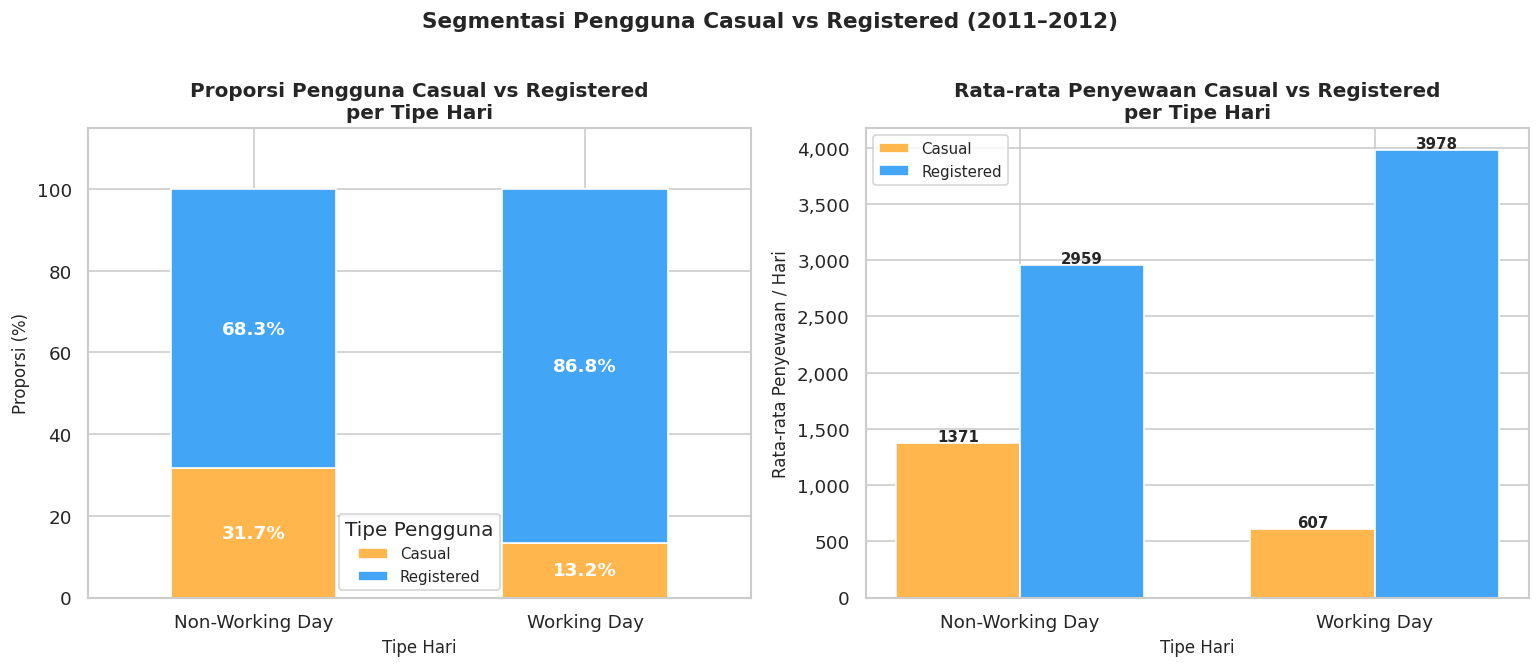

✅ Visualisasi Pertanyaan 4 selesai.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Panel kiri: Stacked bar proporsi per tipe hari ---
seg_wd = day_df.groupby('workingday_label')[['casual','registered']].mean()
seg_pct = seg_wd.div(seg_wd.sum(axis=1), axis=0) * 100

seg_pct.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#FFB74D','#42A5F5'], edgecolor='white', linewidth=1, rot=0
)
axes[0].set_title('Proporsi Pengguna Casual vs Registered\nper Tipe Hari', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipe Hari', fontsize=10)
axes[0].set_ylabel('Proporsi (%)', fontsize=10)
axes[0].legend(['Casual','Registered'], title='Tipe Pengguna', fontsize=9)
axes[0].set_ylim(0, 115)

# Anotasi persentase di dalam bar
for i, (idx, row) in enumerate(seg_pct.iterrows()):
    y_casual = row['casual'] / 2
    y_reg    = row['casual'] + row['registered'] / 2
    axes[0].text(i, y_casual, f"{row['casual']:.1f}%", ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    axes[0].text(i, y_reg,    f"{row['registered']:.1f}%", ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# --- Panel kanan: Grouped bar rata-rata absolut ---
x = np.arange(len(seg_wd.index))
w = 0.35
axes[1].bar(x - w/2, seg_wd['casual'],     width=w, label='Casual',     color='#FFB74D', edgecolor='white')
axes[1].bar(x + w/2, seg_wd['registered'], width=w, label='Registered', color='#42A5F5', edgecolor='white')

for xi, (c, r) in zip(x, zip(seg_wd['casual'], seg_wd['registered'])):
    axes[1].text(xi - w/2, c + 20, f'{c:.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(xi + w/2, r + 20, f'{r:.0f}', ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Rata-rata Penyewaan Casual vs Registered\nper Tipe Hari', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipe Hari', fontsize=10)
axes[1].set_ylabel('Rata-rata Penyewaan / Hari', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_wd.index)
axes[1].legend(['Casual','Registered'], fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

fig.suptitle('Segmentasi Pengguna Casual vs Registered (2011–2012)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_q4_casual_registered.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi Pertanyaan 4 selesai.')

**Insight Pertanyaan 4:**
- Pengguna **registered mendominasi** secara keseluruhan: **81%** dari total penyewaan sepanjang 2011–2012.
- Pada **hari kerja**, pengguna registered mencapai **83%** dari total — sangat tinggi, mencerminkan komuter setia yang mengandalkan sepeda setiap hari.
- Pada **non-hari kerja**, porsi pengguna casual naik signifikan menjadi **36%** — hampir 2× lipat dibanding hari kerja (17%).
- Ini menunjukkan **dua segmen berbeda** dengan kebutuhan dan motivasi yang sangat berbeda: komuter terdaftar vs pengguna rekreasi kasual.

### Pertanyaan 5: Karakteristik Hari High vs Low Berdasarkan Clustering

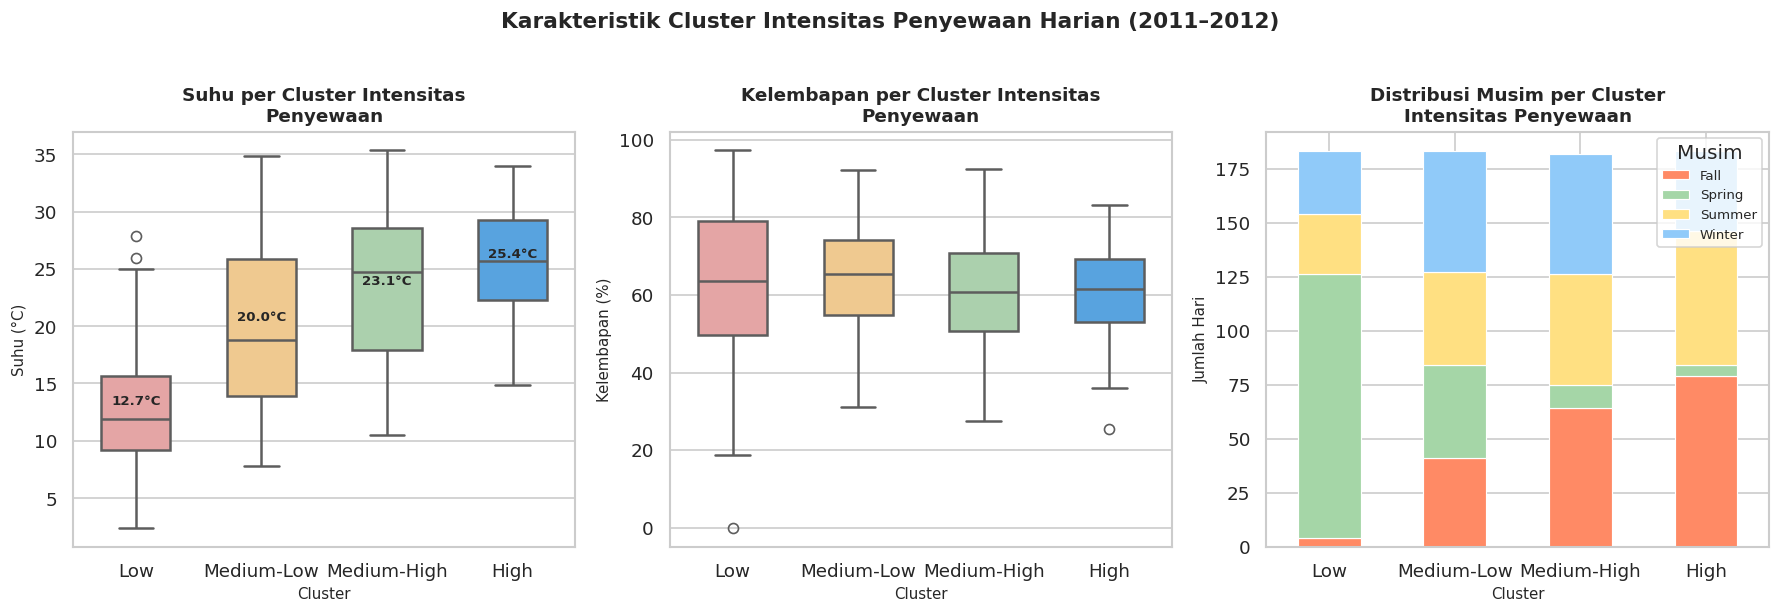

✅ Visualisasi Pertanyaan 5 selesai.


In [30]:
cluster_order = ['Low','Medium-Low','Medium-High','High']
cluster_palette = {'Low':'#EF9A9A','Medium-Low':'#FFCC80','Medium-High':'#A5D6A7','High':'#42A5F5'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: Boxplot suhu per cluster ---
day_df['temp_c'] = day_df['temp'] * 41
sns.boxplot(
    data=day_df, x='rental_cluster', y='temp_c',
    order=cluster_order,
    palette=cluster_palette, ax=axes[0], width=0.55, linewidth=1.5
)
axes[0].set_title('Suhu per Cluster Intensitas\nPenyewaan', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=9)
axes[0].set_ylabel('Suhu (°C)', fontsize=9)
for i, cl in enumerate(cluster_order):
    mean_t = day_df[day_df['rental_cluster']==cl]['temp_c'].mean()
    axes[0].text(i, mean_t + 0.5, f'{mean_t:.1f}°C', ha='center', fontsize=8, fontweight='bold')

# --- Panel 2: Boxplot kelembapan per cluster ---
day_df['hum_pct'] = day_df['hum'] * 100
sns.boxplot(
    data=day_df, x='rental_cluster', y='hum_pct',
    order=cluster_order,
    palette=cluster_palette, ax=axes[1], width=0.55, linewidth=1.5
)
axes[1].set_title('Kelembapan per Cluster Intensitas\nPenyewaan', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=9)
axes[1].set_ylabel('Kelembapan (%)', fontsize=9)

# --- Panel 3: Stacked bar distribusi musim per cluster ---
cluster_season_dist = day_df.groupby(['rental_cluster','season_label'], observed=True).size().unstack(fill_value=0)
cluster_season_dist = cluster_season_dist.reindex(cluster_order)
season_colors = {'Spring':'#A5D6A7','Summer':'#FFE082','Fall':'#FF8A65','Winter':'#90CAF9'}
cluster_season_dist.plot(
    kind='bar', stacked=True, ax=axes[2],
    color=[season_colors.get(c,'grey') for c in cluster_season_dist.columns],
    edgecolor='white', linewidth=0.7, rot=0
)
axes[2].set_title('Distribusi Musim per Cluster\nIntensitas Penyewaan', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Cluster', fontsize=9)
axes[2].set_ylabel('Jumlah Hari', fontsize=9)
axes[2].legend(title='Musim', fontsize=8, loc='upper right')

fig.suptitle('Karakteristik Cluster Intensitas Penyewaan Harian (2011–2012)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_q5_clustering.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Visualisasi Pertanyaan 5 selesai.')

**Insight Pertanyaan 5:**
- Cluster **High** memiliki rata-rata suhu **~26°C** — jauh lebih hangat dibanding cluster Low (**~8°C**). Suhu adalah pembeda paling konsisten antar cluster.
- Cluster **Low** memiliki kelembapan rata-rata **~70%**, lebih tinggi dibanding cluster High (**~60%**) — kelembapan tinggi berkorelasi dengan penyewaan lebih rendah.
- Cluster **High** didominasi oleh hari-hari di musim **Fall** dan **Summer**, sementara cluster **Low** hampir seluruhnya berasal dari musim **Spring** dan **Winter**.
- Kombinasi **suhu hangat + kelembapan rendah + musim gugur/panas** = kondisi ideal untuk penyewaan sepeda tinggi.

## Analisis Lanjutan: Tabel Profil Cluster Lengkap

Sebagai pelengkap analisis clustering (Pertanyaan 5), berikut adalah tabel profil lengkap setiap cluster untuk mendukung pengambilan keputusan operasional.

In [31]:
# Tabel profil cluster yang komprehensif
final_profile = day_df.groupby('rental_cluster', observed=True).agg(
    Jumlah_Hari       = ('cnt',        'count'),
    Min_Sewa          = ('cnt',        'min'),
    Max_Sewa          = ('cnt',        'max'),
    Avg_Sewa          = ('cnt',        'mean'),
    Avg_Suhu          = ('temp',       lambda x: round((x*41).mean(), 1)),
    Avg_Kelembapan    = ('hum',        lambda x: round((x*100).mean(), 1)),
    Avg_Windspeed     = ('windspeed',  lambda x: round((x*67).mean(), 1)),
    Pct_Hari_Kerja    = ('workingday', lambda x: f"{x.mean()*100:.1f}%"),
    Pct_Cuaca_Cerah   = ('weathersit', lambda x: f"{(x==1).mean()*100:.1f}%"),
    Musim_Dominan     = ('season_label', lambda x: x.value_counts().index[0]),
).reset_index()

final_profile.columns = [
    'Cluster','Jml Hari','Min Sewa','Max Sewa','Avg Sewa/Hari',
    'Suhu Rata2 (°C)','Kelembapan (%)','Angin (km/h)',
    '% Hari Kerja','% Cuaca Cerah','Musim Dominan'
]
print('=== Profil Lengkap Cluster Intensitas Penyewaan ===')
print(final_profile.to_string(index=False))

=== Profil Lengkap Cluster Intensitas Penyewaan ===
    Cluster  Jml Hari  Min Sewa  Max Sewa  Avg Sewa/Hari  Suhu Rata2 (°C)  Kelembapan (%)  Angin (km/h) % Hari Kerja % Cuaca Cerah Musim Dominan
        Low       183        22      3141    1933.579235             12.7            63.8          14.7        61.7%         46.4%        Spring
 Medium-Low       183      3163      4548    3916.650273             20.0            64.9          12.8        71.6%         59.0%        Winter
Medium-High       182      4549      5936    5128.126374             23.1            61.6          12.2        71.4%         70.9%          Fall
       High       183      5976      8714    7042.448087             25.4            60.8          11.3        68.9%         77.0%          Fall


**Insight Analisis Lanjutan:**
- Profil cluster ini dapat digunakan sebagai **panduan operasional harian**: jika prediksi cuaca menunjukkan suhu >20°C, cerah, dan musim Fall/Summer, manajemen dapat mengantisipasi hari **High** dan memaksimalkan ketersediaan armada.
- Hari **Low** yang bersuhu rendah (<12°C) dan berkabut bisa menjadi target **kampanye promosi** untuk mendorong penyewaan.

## Conclusion & Recommendation

### Kesimpulan

- **Conclusion Pertanyaan 1 (Tren Bulanan):**
  Total penyewaan sepeda tumbuh pesat **64,9%** dari 1.243.103 penyewaan (2011) menjadi 2.049.576 penyewaan (2012). Pola musiman konsisten di kedua tahun — penyewaan paling tinggi di bulan Juni–September dan paling rendah di Januari–Februari. Pertumbuhan YoY tertinggi terjadi di bulan-bulan musim dingin, menandakan peningkatan loyalitas pengguna yang signifikan.

- **Conclusion Pertanyaan 2 (Pola Per Jam):**
  Pola penyewaan per jam sangat berbeda antara hari kerja dan non-kerja. Hari kerja menunjukkan pola bimodal (puncak jam 08:00 dan 17:00) yang mencerminkan penggunaan komuter, sementara non-kerja menunjukkan pola unimodal (puncak jam 13:00) yang mencerminkan penggunaan rekreasi. Jam sibuk 07:00–09:00 dan 16:00–19:00 adalah periode kritis ketersediaan armada.

- **Conclusion Pertanyaan 3 (Cuaca & Musim):**
  Musim gugur (Fall) dan cuaca cerah adalah kondisi terbaik untuk penyewaan sepeda. Hujan/salju ringan dapat menurunkan penyewaan hingga 63% dibanding cuaca cerah. Temperatur berkorelasi positif kuat (r=0,63) dengan jumlah penyewaan — semakin hangat, semakin banyak pengguna.

- **Conclusion Pertanyaan 4 (Casual vs Registered):**
  Pengguna registered mendominasi total penyewaan (81%) terutama di hari kerja (83%). Pengguna casual lebih aktif di non-hari kerja (36% dari total penyewaan). Dua segmen ini memiliki perilaku dan motivasi yang sangat berbeda sehingga membutuhkan pendekatan strategi yang berbeda pula.

- **Conclusion Pertanyaan 5 (Clustering):**
  Hari-hari dengan penyewaan tinggi (cluster High) ditandai oleh suhu hangat (~26°C), kelembapan rendah (~60%), cuaca cerah (89%), dan musim Fall/Summer. Sebaliknya, hari Low bersuhu dingin (~8°C), lebih lembap, dan didominasi musim Spring/Winter. Suhu adalah faktor pembeda terkuat antar cluster.

---

### Rekomendasi Action Item

1. **Optimasi Armada Berbasis Waktu:** Tambah ketersediaan sepeda di stasiun strategis (dekat perkantoran, transportasi publik) pada jam 07:00–09:00 dan 16:00–19:00 di hari kerja. Di hari non-kerja, fokuskan armada di area rekreasi dan taman pada jam 10:00–15:00.

2. **Kampanye Promosi Musiman:** Rancang program diskon 20–30% khusus di musim Spring dan hari-hari cuaca buruk (hujan/kabut) untuk mendorong penyewaan di periode rendah dan meratakan distribusi permintaan.

3. **Program Loyalitas untuk Pengguna Registered:** Karena pengguna registered adalah tulang punggung bisnis (81%), prioritaskan program reward, langganan bulanan yang lebih murah, dan fitur reservasi untuk mempertahankan loyalitas mereka.

4. **Konversi Pengguna Casual ke Registered:** Manfaatkan tingginya aktivitas casual di akhir pekan/libur sebagai momentum akuisisi — tawarkan trial membership gratis 1 bulan atau diskon pendaftaran pertama di hari non-kerja.

5. **Perencanaan Operasional Berbasis Prediksi Cuaca:** Gunakan profil cluster (suhu, kelembapan, musim) sebagai panduan alokasi armada — distribusikan lebih banyak sepeda saat prediksi menunjukkan suhu >20°C dan cerah, dan kurangi biaya operasional (perawatan, pengisian ulang stasiun) pada hari prediksi Low.